Randomly chosen gate sequence (applied left to right):
   |0>  --Z--X--Y--H--X-->  |psi_final>

--- Analytical Calculation (step by step) ---
  start        : [1.+0.j 0.+0.j]
  after 1. Z   : [1.+0.j 0.+0.j]
  after 2. X   : [0.+0.j 1.+0.j]
  after 3. Y   : [0.-1.j 0.+0.j]
  after 4. H   : [0.-0.7071j 0.-0.7071j]
  after 5. X   : [0.-0.7071j 0.-0.7071j]
(If a step looks unchanged, that is genuine - e.g. X leaves any
 state with equal amplitudes alone, and Z leaves |0> alone.)

Combined unitary  U = G5.G4.G3.G2.G1 :
[[0.-0.7071j 0.+0.7071j]
 [0.-0.7071j 0.-0.7071j]]

Analytical final state:
  |psi> = (+0.0000-0.7071j)|0> + (+0.0000-0.7071j)|1>
  probabilities: P(0) = 0.5000, P(1) = 0.5000

--- Qiskit Statevector Simulation ---
Statevector([0.-0.70710678j, 0.-0.70710678j],
            dims=(2,))

Absolute Numerical Difference (analytical vs Qiskit): 0.00000000e+00
STATUS: SUCCESS - analytical result matches the simulator!

--- Shot-based Verification (Aer, 8192 shots) ---
Counts: {'1': 4

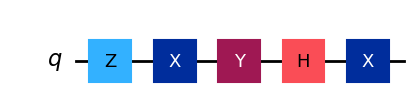

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

# ==============================================================
# WEEK 3 - HARD
# Apply a sequence of FIVE randomly chosen single-qubit gates,
# work out the final state ANALYTICALLY (by multiplying the gate
# matrices by hand with NumPy), then verify it with simulation.
# ==============================================================

# Fixed seed so the notebook is reproducible. Change/remove it to
# get a different random sequence each run.
rng = np.random.default_rng(2023035)

# --- Gate library: matrix + the Qiskit method that applies it -----
GATES = {
    "X": (np.array([[0, 1], [1, 0]], dtype=complex),
          lambda qc: qc.x(0)),
    "Y": (np.array([[0, -1j], [1j, 0]], dtype=complex),
          lambda qc: qc.y(0)),
    "Z": (np.array([[1, 0], [0, -1]], dtype=complex),
          lambda qc: qc.z(0)),
    "H": (np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2),
          lambda qc: qc.h(0)),
}

# --- 1. Pick five random gates ------------------------------------
names = list(GATES.keys())
sequence = [names[i] for i in rng.integers(0, len(names), size=5)]

print("Randomly chosen gate sequence (applied left to right):")
print("   |0>  --" + "--".join(sequence) + "-->  |psi_final>")

# --- 2. Build the circuit -----------------------------------------
qc = QuantumCircuit(1)
for g in sequence:
    GATES[g][1](qc)

# --- 3. ANALYTICAL solution ---------------------------------------
# A gate applied LATER sits on the LEFT in matrix multiplication:
#   |psi> = G5 . G4 . G3 . G2 . G1 . |0>
print("\n--- Analytical Calculation (step by step) ---")
psi = np.array([1, 0], dtype=complex)          # start in |0>
print(f"  start        : {np.round(psi, 4)}")
for i, g in enumerate(sequence, start=1):
    psi = GATES[g][0] @ psi
    print(f"  after {i}. {g}   : {np.round(psi, 4)}")

print("(If a step looks unchanged, that is genuine - e.g. X leaves any")
print(" state with equal amplitudes alone, and Z leaves |0> alone.)")

U_total = np.eye(2, dtype=complex)
for g in sequence:
    U_total = GATES[g][0] @ U_total            # newest gate on the left

print("\nCombined unitary  U = G5.G4.G3.G2.G1 :")
print(np.round(U_total, 4))
print("\nAnalytical final state:")
print(f"  |psi> = ({psi[0]:+.4f})|0> + ({psi[1]:+.4f})|1>")
print(f"  probabilities: P(0) = {abs(psi[0]) ** 2:.4f}, "
      f"P(1) = {abs(psi[1]) ** 2:.4f}")

# --- 4. Verify with Qiskit's statevector simulation ---------------
state = Statevector.from_instruction(qc)
print("\n--- Qiskit Statevector Simulation ---")
print(state)

max_diff = np.max(np.abs(state.data - psi))
print(f"\nAbsolute Numerical Difference (analytical vs Qiskit): "
      f"{max_diff:.8e}")
print("STATUS: SUCCESS - analytical result matches the simulator!"
      if np.isclose(max_diff, 0.0, atol=1e-9)
      else "STATUS: FAILED - mismatch detected.")

# --- 5. Extra check: shot-based measurement -----------------------
SHOTS = 8192
qc_meas = qc.copy()
qc_meas.measure_all()
counts = AerSimulator().run(qc_meas, shots=SHOTS).result().get_counts()

print(f"\n--- Shot-based Verification (Aer, {SHOTS} shots) ---")
print(f"Counts: {counts}")
for bit in ("0", "1"):
    measured = counts.get(bit, 0) / SHOTS
    predicted = abs(psi[int(bit)]) ** 2
    print(f"  |{bit}> : measured = {measured:.4f}, "
          f"predicted = {predicted:.4f}, "
          f"error = {abs(measured - predicted):.4f}")

print("\nNote: measurement can only confirm the PROBABILITIES.")
print("The global/relative phases come from the analytical work above.")

# --- 6. Circuit diagram -------------------------------------------
print("\n--- Quantum Circuit ---")
display(qc.draw(output="mpl", style="iqp"))